In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [23]:
from src.features.indicators import create_technical_indicators
from src.features.date_features import create_all_date_features, create_month_position_features
from src.features.price_action import create_market_microstructure_features
from src.config import RAW_DATA, PROCESSED_DATA, VISUALIZATION_DATA

import pandas as pd

In [39]:
from src.features.feature_selection import get_high_correlation_features
from src.features.transformations import *
import matplotlib.pyplot as plt


In [25]:
import seaborn as sns

In [26]:
df = pd.read_csv(
    RAW_DATA / "raw.csv",
    index_col="Date",
    parse_dates=True
)

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2020-06-29,67.290001,67.333336,63.234669,64.600670,135396000
2020-06-30,71.987335,72.512665,66.915337,67.099998,253777500
2020-07-01,74.641998,75.688667,72.033333,72.199997,199903500
2020-07-02,80.577332,81.866669,79.040001,81.431999,258751500
2020-07-06,91.438667,91.852669,84.402664,85.112663,308548500


In [27]:
df = create_technical_indicators(df)

In [28]:
df = create_market_microstructure_features(df)
df.head()

,Close,High,Low,Open,Volume,rsi,EMA_SLOW,EMA_FAST,macd,Signal_line,...,%K,%D,MA_FAST,MA_SLOW,intraday_momentum,volume_weighted_return,money_flow_volume,upper_shadow_ratio,lower_shadow_ratio,close_position_in_range
Date,,,,,,,,,,,,,,,,,,,,,
2020-06-29,67.290001,67.333336,63.234669,64.600670,135396000,NaN,67.290001,67.290001,0.000000,0.000000,...,NaN,NaN,NaN,NaN,2.689331,NaN,1.325329e+08,0.000644,0.020300,0.989427
2020-06-30,71.987335,72.512665,66.915337,67.099998,253777500,NaN,67.637952,68.012668,0.374716,0.074943,...,NaN,NaN,NaN,NaN,4.887337,1.771553e+07,2.061416e+08,0.007298,0.002565,0.906146
2020-07-01,74.641998,75.688667,72.033333,72.199997,199903500,NaN,68.156770,69.032565,0.875795,0.235114,...,NaN,NaN,NaN,NaN,2.442001,7.371803e+06,8.542271e+07,0.014023,0.002233,0.713660
2020-07-02,80.577332,81.866669,79.040001,81.431999,258751500,NaN,69.076811,70.808683,1.731871,0.534465,...,NaN,NaN,NaN,NaN,-0.854668,2.057523e+07,2.270118e+07,0.005394,0.019079,0.543867
2020-07-06,91.438667,91.852669,84.402664,85.112663,308548500,NaN,70.733245,73.982526,3.249281,1.077428,...,NaN,NaN,NaN,NaN,6.326004,4.159047e+07,2.742560e+08,0.004528,0.007765,0.944429


In [29]:
df = create_all_date_features(df)

In [35]:
df.to_csv(VISUALIZATION_DATA / "tesla_features.csv")

In [30]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'rsi', 'EMA_SLOW', 'EMA_FAST',
       'macd', 'Signal_line', 'middle_band', 'upper_band', 'lower_band',
       'above_bb_high', 'below_bb_low', 'TR', '+DM', '-DM', 'Smoothed +DM',
       'Smoothed -DM', 'Smoothed TR', '+DI', '-DI', 'DX', 'ADX', 'OBV', 'PVT',
       'Signal Line_PVT', 'VROC', 'rolling_min', 'rolling_max', '%K', '%D',
       'MA_FAST', 'MA_SLOW', 'intraday_momentum', 'volume_weighted_return',
       'money_flow_volume', 'upper_shadow_ratio', 'lower_shadow_ratio',
       'close_position_in_range', 'day_of_week', 'month', 'quarter',
       'day_of_year', 'week_of_year', 'is_last_day_of_month',
       'is_first_day_of_month'],
      dtype='object')

In [31]:
binary_cols = ['is_last_day_of_month', 'is_first_day_of_month',
               'above_bb_high', 'below_bb_low']

# Check imbalance instead
for col in binary_cols:
    print(f"{col}: {df[col].mean()*100:.1f}% positive")

is_last_day_of_month: 3.4% positive
is_first_day_of_month: 3.1% positive
above_bb_high: 6.9% positive
below_bb_low: 5.0% positive


In [32]:
df = create_month_position_features(df)

In [34]:
df = df.drop(columns=['is_last_day_of_month',
      'is_first_day_of_month', 
      # Redundant intermediate calculations
    'EMA_FAST', 'EMA_SLOW',         # already in macd
    'Signal Line_PVT',         # already in PVT
    'rolling_min', 'rolling_max',  # already in %K
    'TR', '+DM', '-DM', 'DX', # already in ADX
    'Smoothed +DM', 'Smoothed -DM', 'Smoothed TR',
      ])

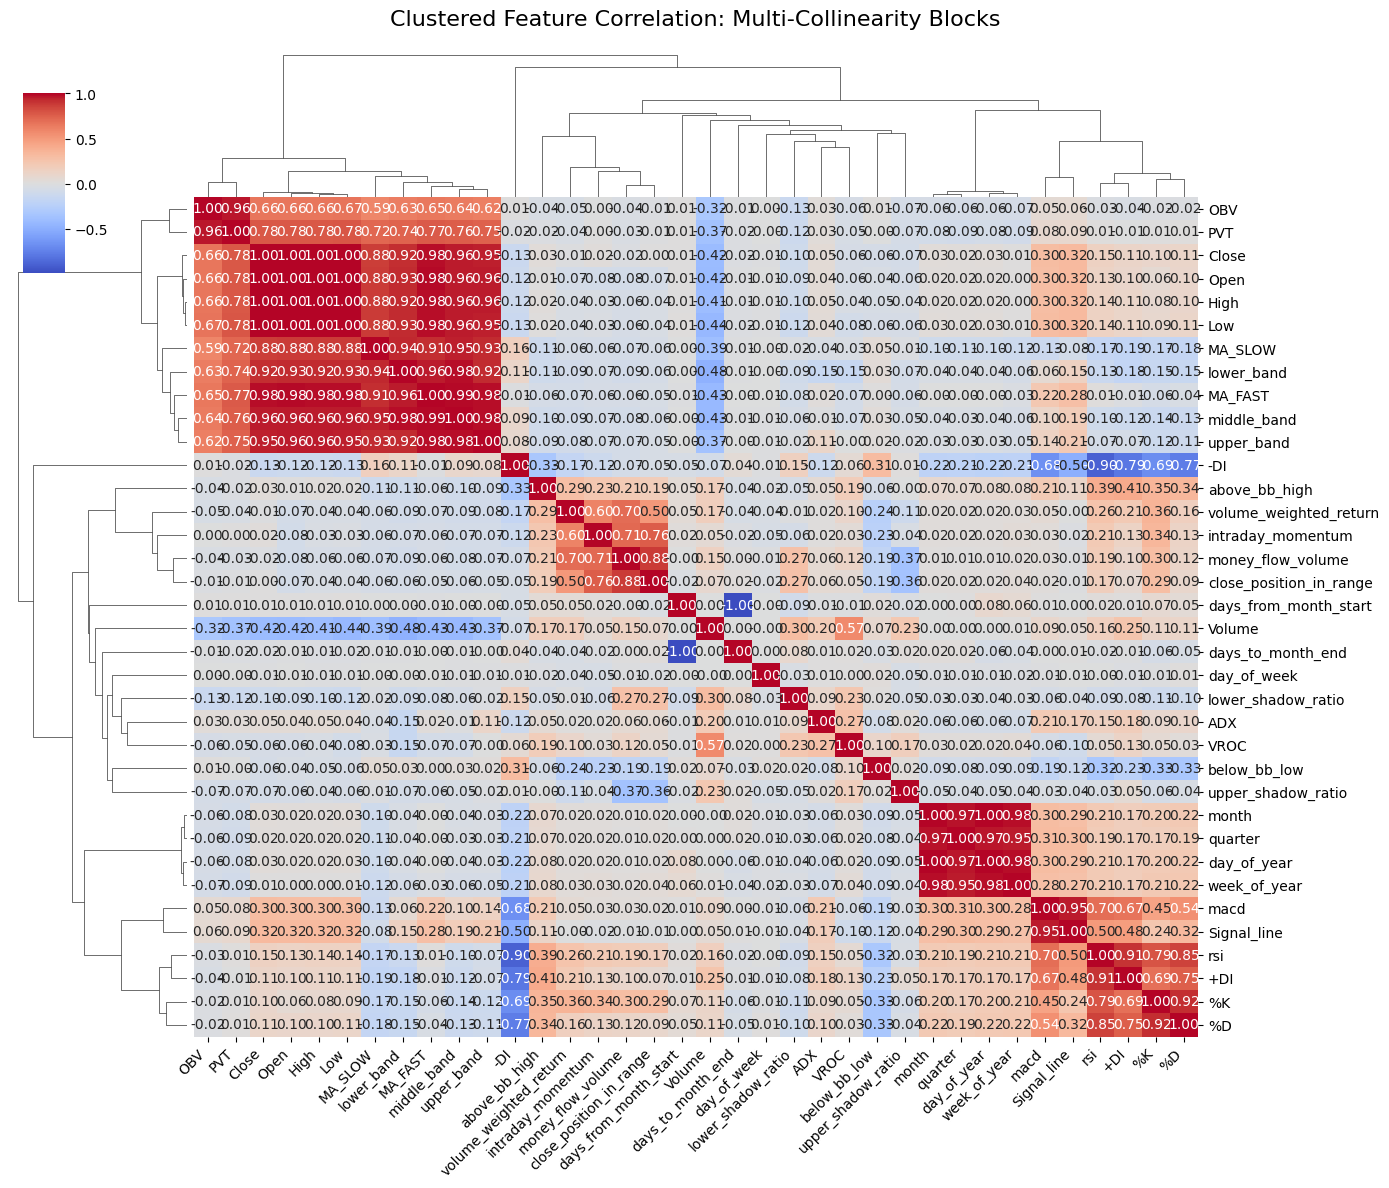

In [35]:
corr_matrix = df.corr()

# Create a heatmap
g = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    figsize=(14, 12),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

# Rotate labels to prevent overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.figure.suptitle('Clustered Feature Correlation: Multi-Collinearity Blocks', y=1.02, fontsize=16)
plt.show()

In [36]:
cols_to_drop = get_high_correlation_features(df)
print(cols_to_drop)

['High', 'Low', 'Open', 'Signal_line', 'middle_band', 'upper_band', 'lower_band', '+DI', 'PVT', '%D', 'MA_FAST', 'MA_SLOW', 'quarter', 'day_of_year', 'week_of_year', 'days_to_month_end']


In [37]:
df = df.drop(columns=cols_to_drop)

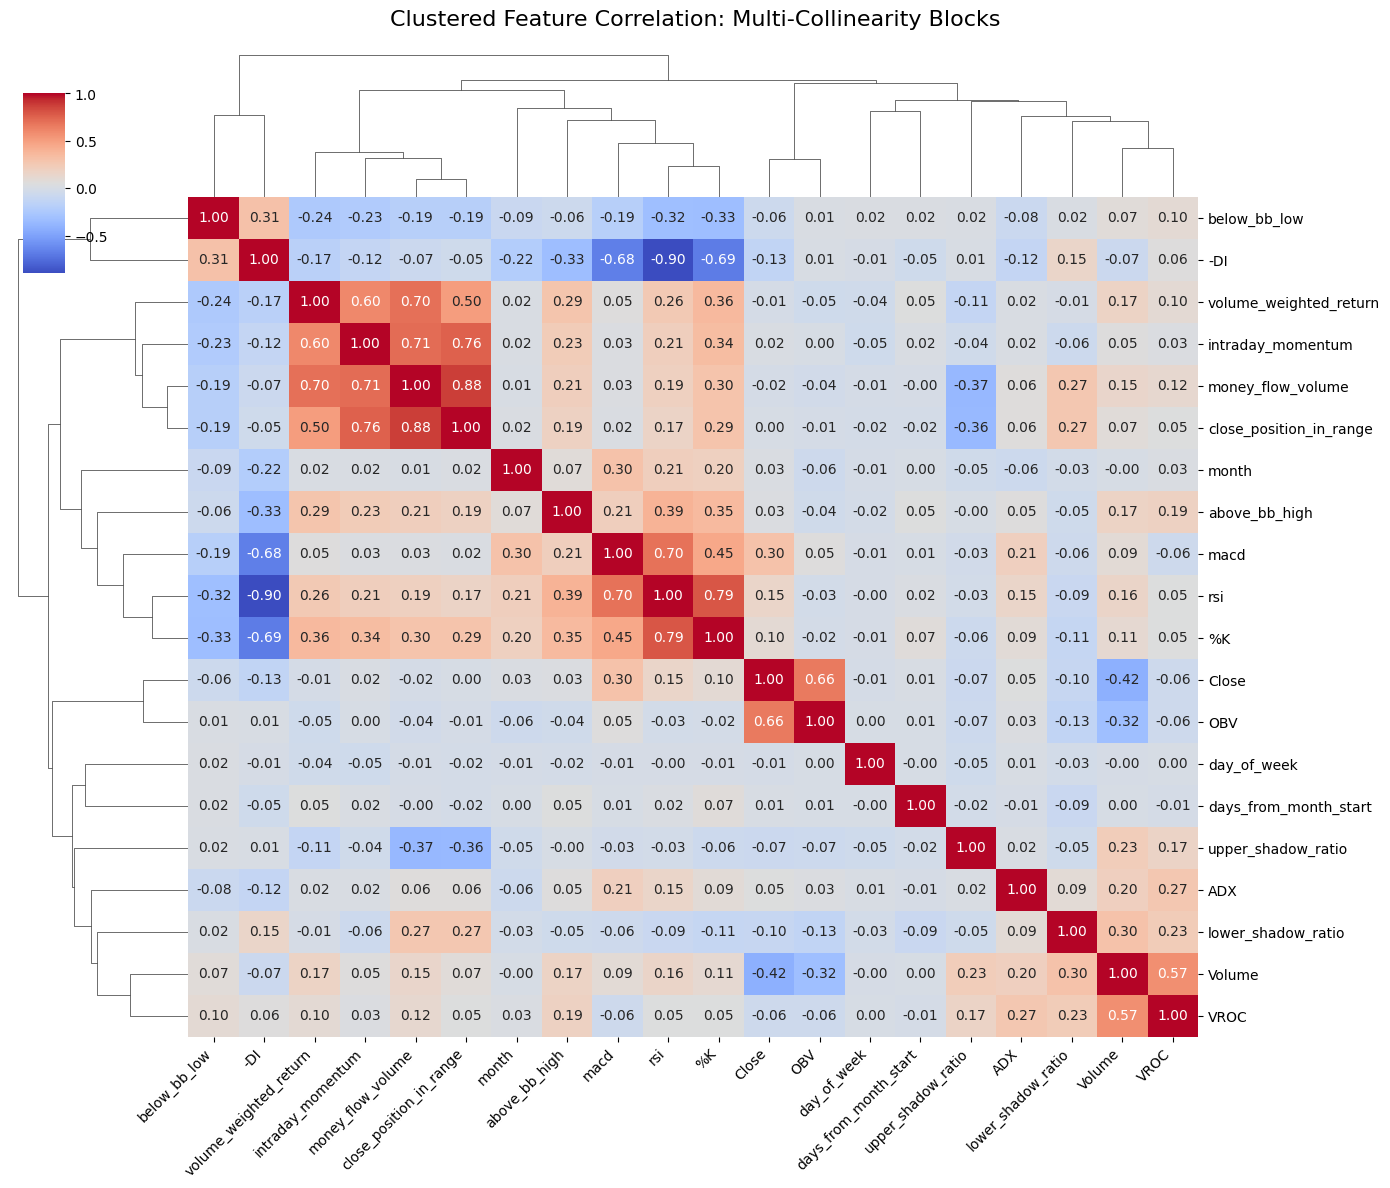

In [38]:
corr_matrix = df.corr()

# Create a heatmap
g = sns.clustermap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    figsize=(14, 12),
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15)
)

# Rotate labels to prevent overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

g.figure.suptitle('Clustered Feature Correlation: Multi-Collinearity Blocks', y=1.02, fontsize=16)
plt.show()

In [41]:
df.isna().sum()

Close                       0
Volume                      0
rsi                        13
macd                        0
above_bb_high               0
below_bb_low                0
-DI                        13
ADX                        26
OBV                         0
VROC                       30
%K                         13
intraday_momentum           0
volume_weighted_return      1
money_flow_volume           0
upper_shadow_ratio          0
lower_shadow_ratio          0
close_position_in_range     0
day_of_week                 0
month                       0
days_from_month_start       0
dtype: int64

In [42]:
df.duplicated().value_counts()

False    1462
Name: count, dtype: int64

In [43]:
df.describe()

,Close,Volume,rsi,macd,above_bb_high,below_bb_low,-DI,ADX,OBV,VROC,%K,intraday_momentum,volume_weighted_return,money_flow_volume,upper_shadow_ratio,lower_shadow_ratio,close_position_in_range,day_of_week,month,days_from_month_start
count,1462.000000,1.462000e+03,1449.000000,1462.000000,1462.000000,1462.000000,1449.000000,1436.000000,1.462000e+03,1432.000000,1449.000000,1462.000000,1.461000e+03,1.462000e+03,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,261.933136,1.056626e+08,51.873811,1.490228,0.069083,0.049932,23.184244,36.160835,9.007653e+09,8.855154,52.870649,-0.099273,4.498450e+05,5.801454e+06,0.010490,0.011763,0.515704,2.019152,6.594391,14.713406
std,87.232919,5.408552e+07,17.987884,11.396148,0.253683,0.217878,10.685662,16.783682,3.002227e+09,55.850424,36.679086,8.321526,6.752204e+06,7.665078e+07,0.009662,0.010499,0.309048,1.398019,3.474211,8.760128
min,67.290001,2.940180e+07,6.919326,-35.583228,0.000000,0.000000,-0.853584,7.804927,0.000000e+00,-91.741857,0.000000,-50.033356,-7.296101e+07,-4.910729e+08,0.000000,0.000000,0.000162,0.000000,1.000000,0.000000
25%,200.844997,7.017875e+07,39.605994,-6.599998,0.000000,0.000000,15.149521,23.013260,6.964878e+09,-27.193367,17.220737,-4.389999,-1.696709e+06,-4.439184e+07,0.003555,0.004365,0.231616,1.000000,3.000000,7.000000
50%,245.476669,9.376550e+07,50.968524,1.519651,0.000000,0.000000,22.987579,32.268794,9.277016e+09,-3.418660,54.219869,-0.014999,1.038021e+05,3.682062e+06,0.007953,0.009296,0.516632,2.000000,7.000000,15.000000
75%,319.334999,1.232412e+08,63.759760,7.142050,0.000000,0.000000,30.987031,47.666509,1.154628e+10,29.065874,89.427825,4.497494,2.176413e+06,5.396081e+07,0.014918,0.016131,0.796737,3.000000,10.000000,22.000000
max,489.880005,6.663786e+08,97.529933,40.538606,1.000000,1.000000,55.022874,91.876995,1.390458e+10,681.735382,100.000000,47.510010,4.978942e+07,6.663786e+08,0.090838,0.097767,1.000000,4.000000,12.000000,30.000000


In [44]:
df.dropna(inplace=True)
df.isna().sum()

Close                      0
Volume                     0
rsi                        0
macd                       0
above_bb_high              0
below_bb_low               0
-DI                        0
ADX                        0
OBV                        0
VROC                       0
%K                         0
intraday_momentum          0
volume_weighted_return     0
money_flow_volume          0
upper_shadow_ratio         0
lower_shadow_ratio         0
close_position_in_range    0
day_of_week                0
month                      0
days_from_month_start      0
dtype: int64

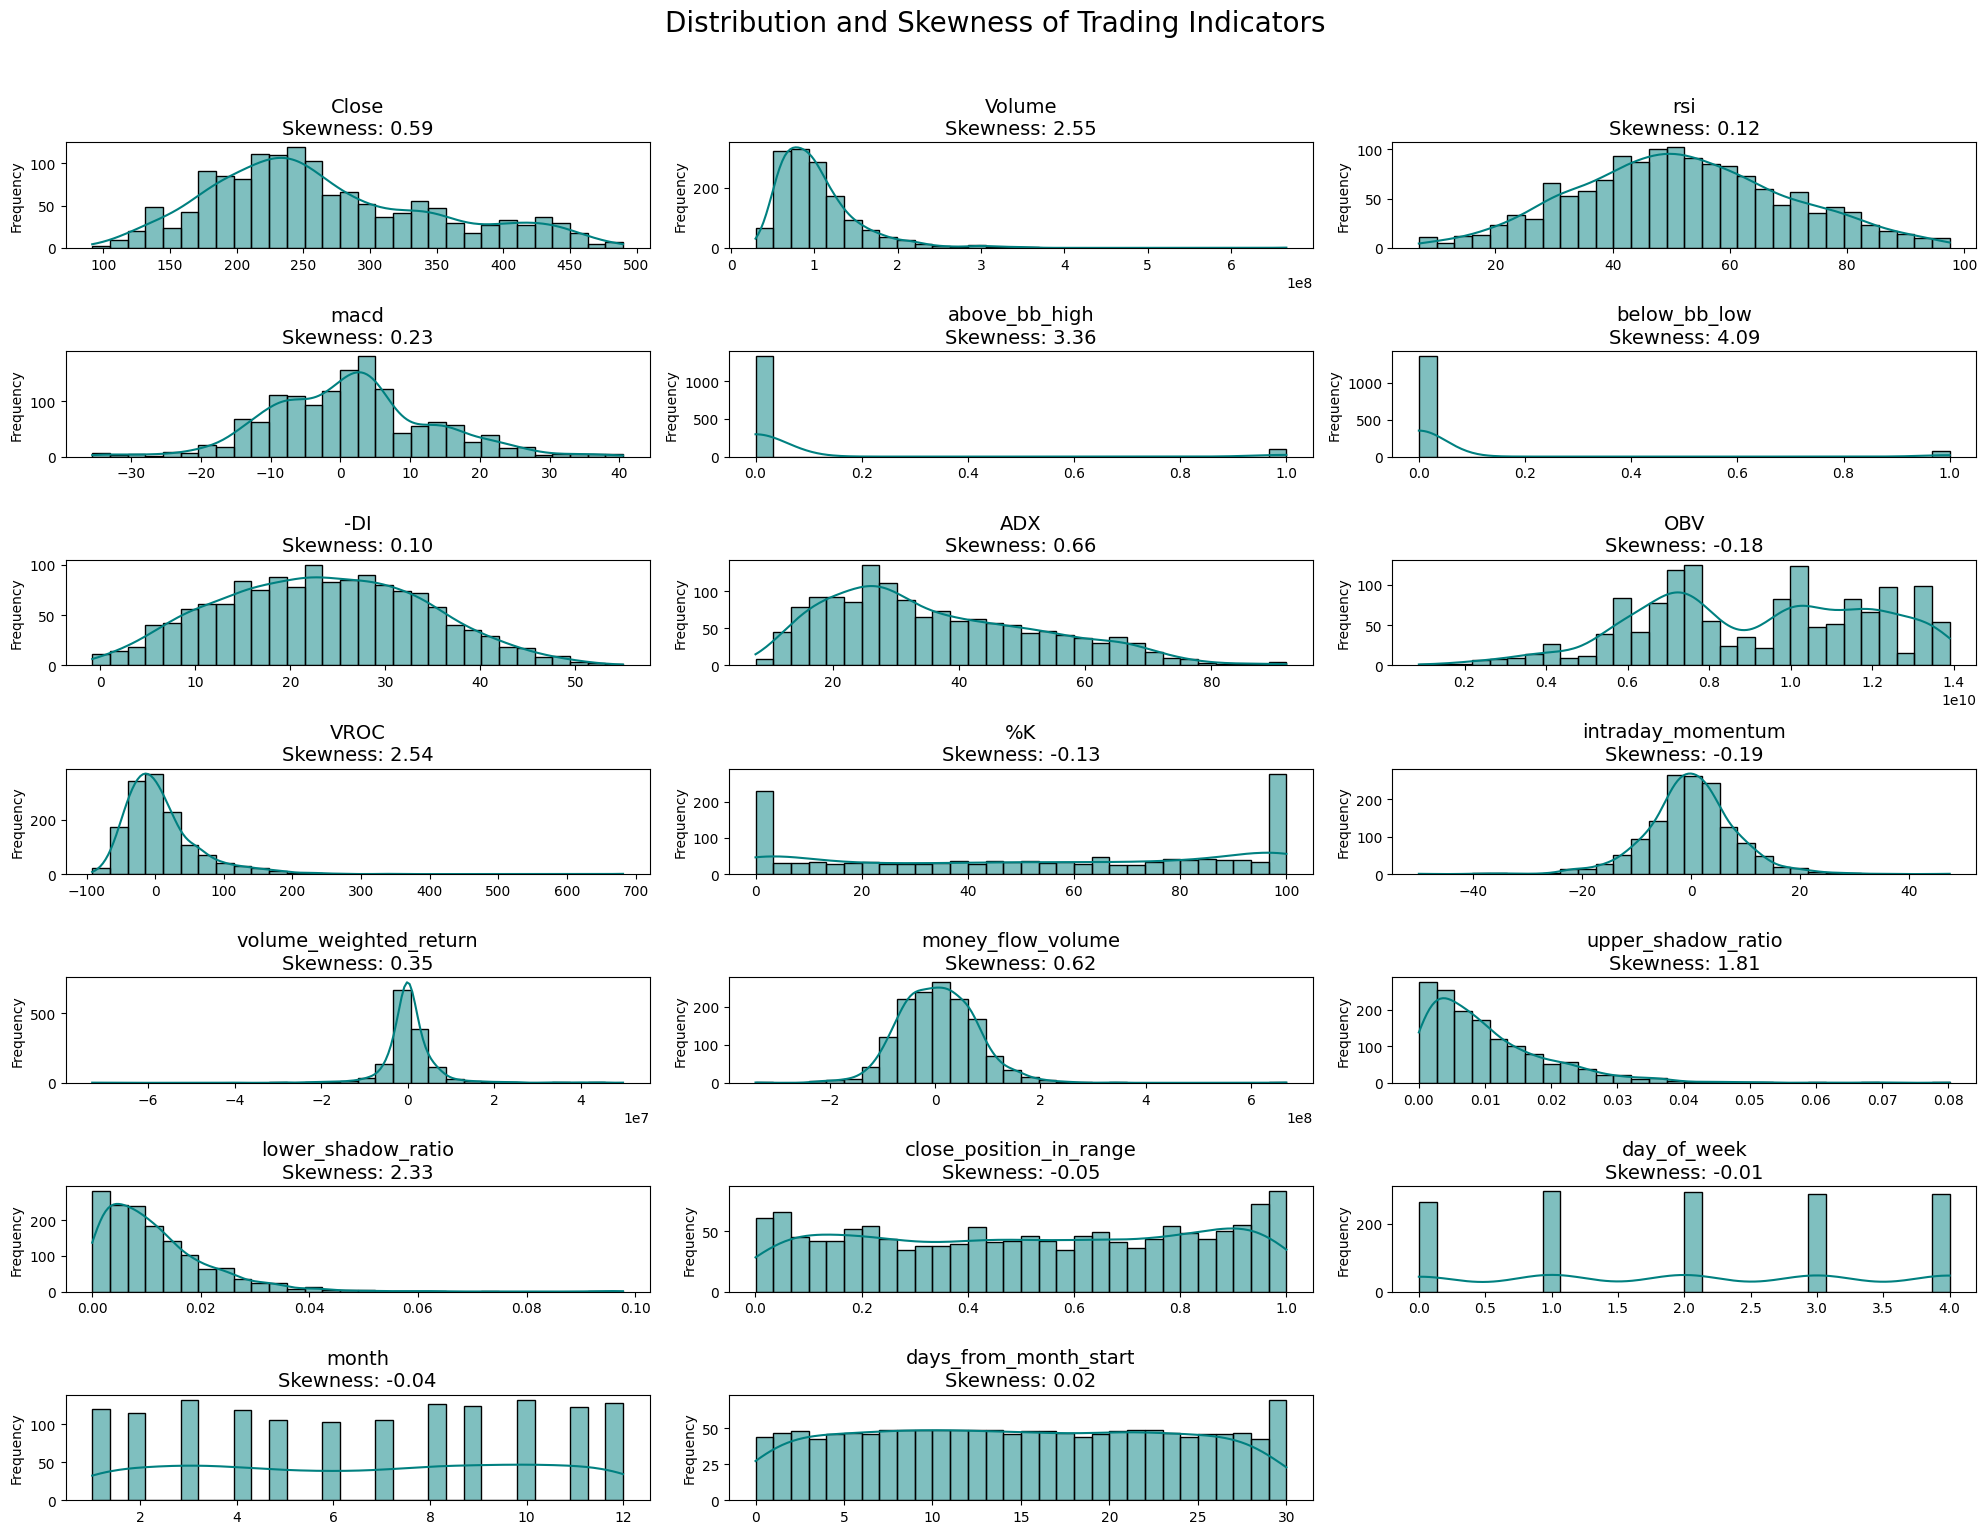

In [45]:
plt.figure(figsize=(20, 15))
plt.suptitle('Distribution and Skewness of Trading Indicators', fontsize=20, y=1.02)

n_cols = 3
n_rows = -(-len(df.columns) // n_cols)

for i, col in enumerate(df.columns):
    plt.subplot(n_rows, n_cols, i + 1)

    # Plotting the histogram
    sns.histplot(df[col].dropna(), kde=True, color='teal', bins=30)

    # Calculating skewness
    skew_val = df[col].skew()

    plt.title(f'{col}\nSkewness: {skew_val:.2f}', fontsize=14)
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Close: Q1=204.73, Q3=321.77, IQR=117.04, Outliers=0 (0.0%)
Volume: Q1=69608700.00, Q3=121091325.00, IQR=51482625.00, Outliers=67 (4.7%)
rsi: Q1=39.50, Q3=63.74, IQR=24.25, Outliers=0 (0.0%)
macd: Q1=-6.75, Q3=6.83, IQR=13.58, Outliers=37 (2.6%)
above_bb_high: Q1=0.00, Q3=0.00, IQR=0.00, Outliers=101 (7.1%)
below_bb_low: Q1=0.00, Q3=0.00, IQR=0.00, Outliers=73 (5.1%)
-DI: Q1=15.22, Q3=31.12, IQR=15.90, Outliers=1 (0.1%)
ADX: Q1=22.96, Q3=47.67, IQR=24.71, Outliers=7 (0.5%)
OBV: Q1=7030134150.00, Q3=11581576900.00, IQR=4551442750.00, Outliers=0 (0.0%)
VROC: Q1=-27.19, Q3=29.07, IQR=56.26, Outliers=78 (5.4%)
%K: Q1=17.08, Q3=89.63, IQR=72.55, Outliers=0 (0.0%)
intraday_momentum: Q1=-4.45, Q3=4.55, IQR=9.00, Outliers=63 (4.4%)
volume_weighted_return: Q1=-1678351.54, Q3=2110228.03, IQR=3788579.57, Outliers=146 (10.2%)
money_flow_volume: Q1=-44444726.65, Q3=53361910.46, IQR=97806637.11, Outliers=19 (1.3%)
upper_shadow_ratio: Q1=0.00, Q3=0.01, IQR=0.01, Outliers=50 (3.5%)
lower_shadow_ratio: 

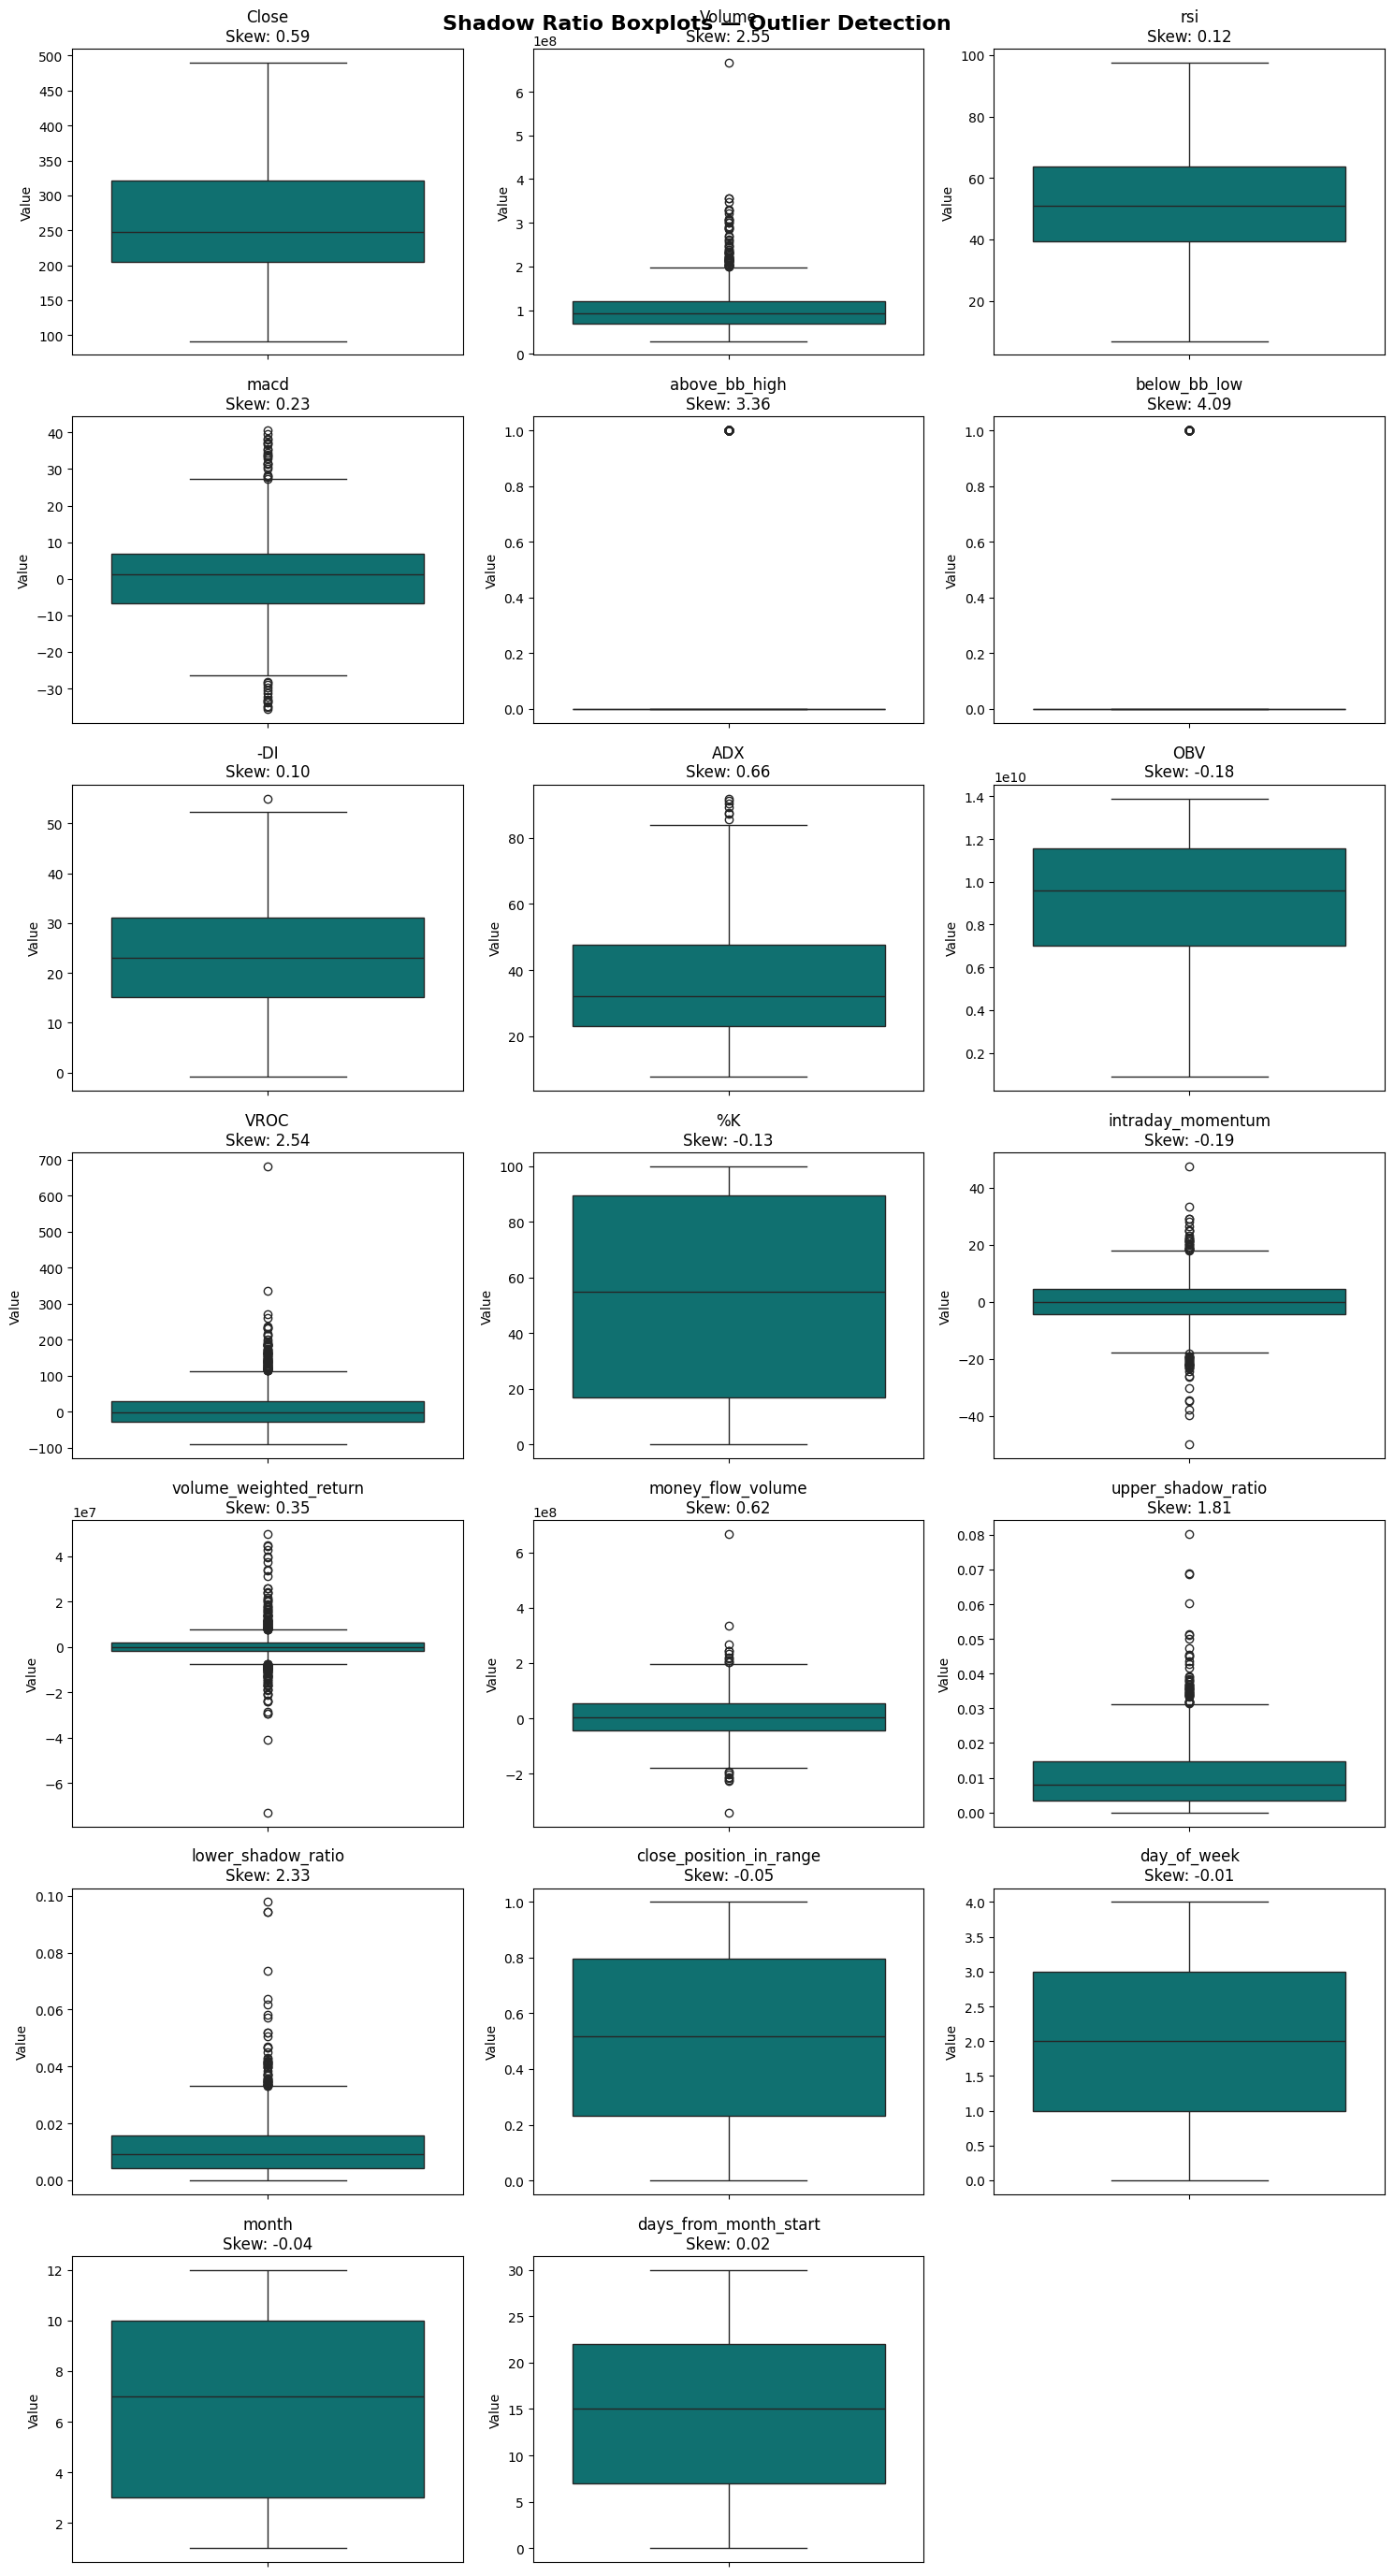

In [49]:
n_cols = 3
n_rows = int(np.ceil(len(df.columns) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
)

axes = axes.flatten()

fig.suptitle(
    "Shadow Ratio Boxplots — Outlier Detection",
    fontsize=16,
    weight="bold",
)

for i, col in enumerate(df.columns):
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="teal",
    )

    axes[i].set_title(
        f"{col}\nSkew: {df[col].skew():.2f}"
    )
    axes[i].set_ylabel("Value")

    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    outlier_count = (
        (df[col] < q1 - 1.5 * iqr)
        | (df[col] > q3 + 1.5 * iqr)
    ).sum()

    print(
        f"{col}: "
        f"Q1={q1:.2f}, "
        f"Q3={q3:.2f}, "
        f"IQR={iqr:.2f}, "
        f"Outliers={outlier_count} "
        f"({outlier_count / len(df) * 100:.1f}%)"
    )

# Hide unused axes
for ax in axes[len(df.columns):]:
    ax.remove()

plt.tight_layout()
plt.show()